In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)

In [23]:
#load and compute damage ratio:

df = pd.read_csv("nfip_claims_harris_tx_clean.csv")
df["damage_ratio"] = df["buildingDamageAmount"] / df["buildingPropertyValue"]

over_100pct = (df["damage_ratio"] > 1.0).sum()
print(f"Claims with damage ratio > 100%: {over_100pct:,} ({over_100pct/len(df):.1%})")

df["damage_ratio"] = df["damage_ratio"].clip(upper=1.0)

Claims with damage ratio > 100%: 55 (0.0%)


/tmp/ipykernel_1502/1975644790.py:3: DtypeWarning: Columns (7,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("nfip_claims_harris_tx_clean.csv")


In [24]:
#check water depth quality:

print(df["waterDepth"].describe())
missing_pct = df["waterDepth"].isnull().mean()
print(f"\nMissing: {df['waterDepth'].isnull().sum():,} ({missing_pct:.1%})")

count    125978.000000
mean          2.739113
std          10.307480
min        -192.000000
25%           0.000000
50%           1.000000
75%           2.000000
max         578.000000
Name: waterDepth, dtype: float64

Missing: 7,735 (5.8%)


In [25]:
#filter to plausible depth range:

depth_df = df[df["waterDepth"].notna()].copy()
before = len(depth_df)
depth_df = depth_df[(depth_df["waterDepth"] >= -4) & (depth_df["waterDepth"] <= 15)]
after = len(depth_df)
print(f"Rows with usable water depth: {after:,} (removed {before - after:,} outliers)")
print(f"This is {after / len(df):.1%} of all cleaned claims.")


Rows with usable water depth: 122,231 (removed 3,747 outliers)
This is 91.4% of all cleaned claims.


In [26]:
#build the depth-damage table:

bins = list(range(-4, 16, 1))
depth_df["depth_bin"] = pd.cut(depth_df["waterDepth"], bins=bins)

curve = depth_df.groupby("depth_bin", observed=True)["damage_ratio"].agg(
    mean_damage_ratio="mean", median_damage_ratio="median", count="count"
).reset_index()

MIN_COUNT = 30
curve["reliable"] = curve["count"] >= MIN_COUNT
curve

,depth_bin,mean_damage_ratio,median_damage_ratio,count,reliable
0,"(-4, -3]",0.096761,0.029854,65,True
1,"(-3, -2]",0.155132,0.049509,80,True
2,"(-2, -1]",0.121604,0.050550,1000,True
3,"(-1, 0]",0.204698,0.105870,36133,True
4,"(0, 1]",0.255517,0.210119,47062,True
5,"(1, 2]",0.367849,0.356986,15500,True
6,"(2, 3]",0.378871,0.365638,7484,True
7,"(3, 4]",0.389913,0.365977,4497,True
8,"(4, 5]",0.406854,0.384076,2680,True
9,"(5, 6]",0.361734,0.317404,1989,True


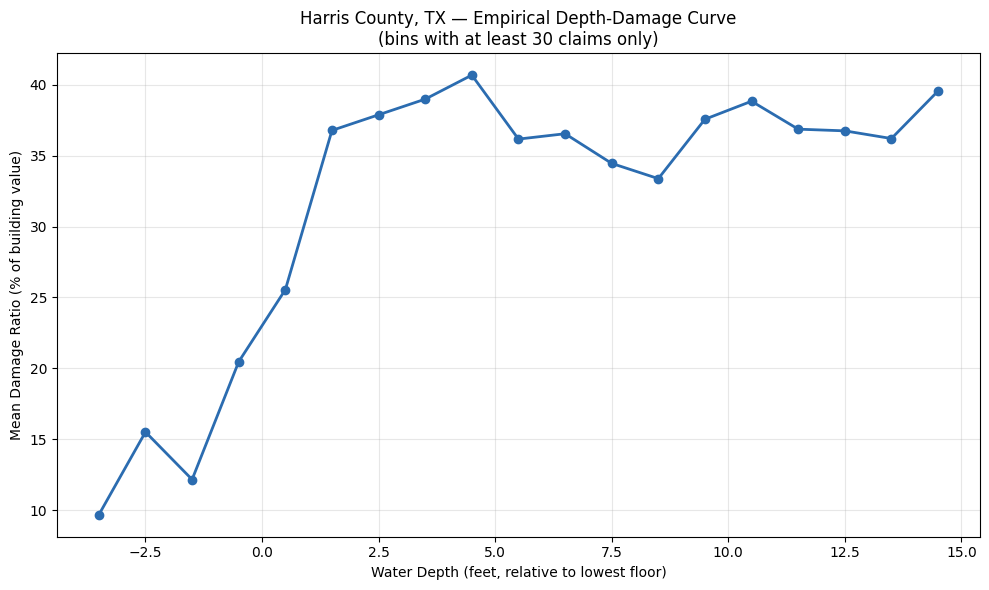

In [27]:
#plot the depth-damage curve:

reliable_curve = curve[curve["reliable"]].copy()
reliable_curve["depth_midpoint"] = reliable_curve["depth_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(10, 6))
plt.plot(reliable_curve["depth_midpoint"], reliable_curve["mean_damage_ratio"] * 100,
         marker="o", color="#2b6cb0", linewidth=2)
plt.xlabel("Water Depth (feet, relative to lowest floor)")
plt.ylabel("Mean Damage Ratio (% of building value)")
plt.title(f"Harris County, TX — Empirical Depth-Damage Curve\n(bins with at least {MIN_COUNT} claims only)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
#zone family grouping:

def map_zone_family(zone):
    if pd.isna(zone) or zone == "UNKNOWN":
        return "Unknown"
    zone = str(zone).strip().upper()
    if zone.startswith("V"):
        return "Coastal High-Risk (V Zone)"
    if zone.startswith("A"):
        return "High-Risk (A Zone)"
    if zone == "X":
        return "Minimal Risk (X Zone)"
    if zone in ("B", "C"):
        return "Moderate/Minimal Risk (B/C Zone)"
    return "Other"

df["zone_family"] = df["floodZoneCurrent"].apply(map_zone_family)
zone_summary = df.groupby("zone_family")["damage_ratio"].agg(
    mean_damage_ratio="mean", median_damage_ratio="median", count="count"
).sort_values("count", ascending=False)
zone_summary["reliable"] = zone_summary["count"] >= MIN_COUNT
zone_summary

,mean_damage_ratio,median_damage_ratio,count,reliable
zone_family,,,,
Unknown,0.230409,0.151238,74738,True
High-Risk (A Zone),0.357227,0.348259,32016,True
Minimal Risk (X Zone),0.296125,0.270136,26660,True
Coastal High-Risk (V Zone),0.187143,0.085676,191,True
Moderate/Minimal Risk (B/C Zone),0.364331,0.338704,108,True


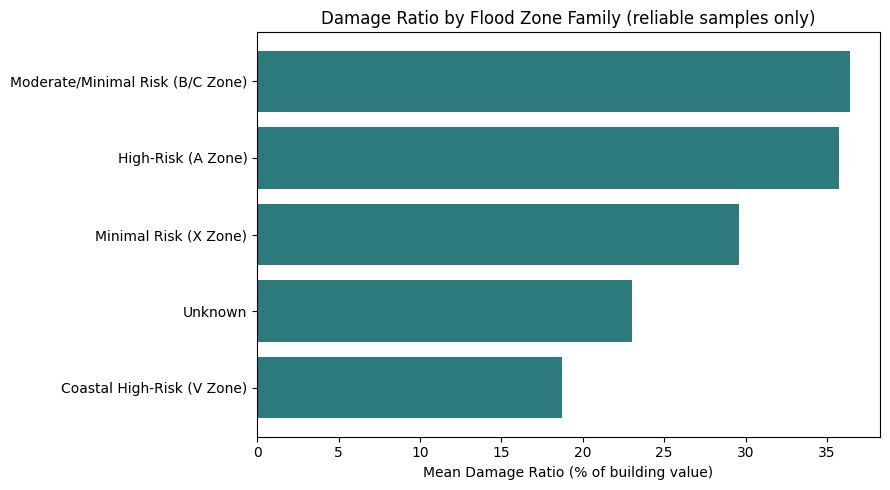

In [29]:
#plot zone family comparison:
reliable_zones = zone_summary[zone_summary["reliable"]].sort_values("mean_damage_ratio")
plt.figure(figsize=(9, 5))
plt.barh(reliable_zones.index, reliable_zones["mean_damage_ratio"] * 100, color="#2c7a7b")
plt.xlabel("Mean Damage Ratio (% of building value)")
plt.title("Damage Ratio by Flood Zone Family (reliable samples only)")
plt.tight_layout()
plt.show()

In [30]:
#save results:

reliable_curve[["depth_bin","mean_damage_ratio","median_damage_ratio","count"]].to_csv("vulnerability_depth_curve.csv", index=False)
zone_summary.to_csv("vulnerability_by_zone_family.csv")
print("Saved")

Saved
